# Skenario 5 — PCA (Principal Component Analysis)

**Tujuan**: Mereduksi 35 fitur menjadi komponen utama (PC) yang lebih kompak, lalu evaluasi dampaknya.

### PCA vs Seleksi Fitur — Perbedaan Mendasar
| Aspek | Seleksi Fitur (B.2–B.4) | PCA (B.5) |
|-------|------------------------|----------|
| Cara kerja | **Memilih subset** fitur asli | **Mentransformasi** semua fitur menjadi komponen baru |
| Hasil | Fitur asli (misal: Bone Density) | Komponen abstrak (PC1, PC2, ...) |
| Interpretabilitas | ✅ Tinggi | ❌ Rendah — PC adalah kombinasi linear fitur asli |
| Redundansi | Bisa masih ada | ✅ Dihilangkan — PC saling orthogonal |
| Supervised? | Filter/Wrapper/Embedded: Ya/Ya/Ya | ❌ Tidak — PCA unsupervised |

### Cara Kerja PCA (Intuitif)
1. Hitung **matriks kovarians** dari semua fitur
2. Cari **eigenvector** (arah varians terbesar) dan **eigenvalue** (besarnya varians di arah tersebut)
3. Urutkan eigenvector berdasarkan eigenvalue dari terbesar ke terkecil
4. Pilih sejumlah PC teratas yang menangkap cukup varians (misal 95%)
5. Proyeksikan data ke ruang PC baru

**Explained variance ratio** = persentase informasi (varians) yang ditangkap oleh masing-masing PC.

In [1]:
# Ubah working directory ke root project agar path data sesuai
import os
if os.path.basename(os.getcwd()) == 'src':
    os.chdir('..')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Library berhasil di-import ✅')

Library berhasil di-import ✅


## 1. Load Data

In [3]:
X_train = pd.read_csv('preprocessed_data/X_train.csv')
X_test  = pd.read_csv('preprocessed_data/X_test.csv')
y_train = pd.read_csv('preprocessed_data/y_train.csv').squeeze()
baseline     = pd.read_csv('baseline_results.csv', index_col='model')
filter_res   = pd.read_csv('filter_method_results.csv', index_col='model')
wrapper_res  = pd.read_csv('wrapper_method_results.csv', index_col='model')
embedded_res = pd.read_csv('embedded_method_results.csv', index_col='model')

LABEL_NAMES = {0:'Dewasa Muda (18-35)', 1:'Dewasa (36-53)', 2:'Paruh Baya (54-71)', 3:'Lansia (72-89)'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'X_train: {X_train.shape} — data sudah di-StandardScaler, siap untuk PCA')

X_train: (3000, 35) — data sudah di-StandardScaler, siap untuk PCA


---
## 2. Analisis Explained Variance
Pertama, fit PCA dengan semua komponen untuk melihat distribusi varians.

In [4]:
# PCA dengan semua komponen untuk analisis
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

# Explained variance
evr = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(evr)

print('=== Explained Variance Ratio (Top 15 PC) ===')
for i in range(min(15, len(evr))):
    print(f'  PC{i+1:2d}: {evr[i]:.4f} (kumulatif: {cumulative_var[i]:.4f} = {cumulative_var[i]*100:.1f}%)')

# Tentukan jumlah PC untuk 95% variance
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f'\nPC untuk 90% variance: {n_90}')
print(f'PC untuk 95% variance: {n_95}')

=== Explained Variance Ratio (Top 15 PC) ===
  PC 1: 0.1168 (kumulatif: 0.1168 = 11.7%)
  PC 2: 0.0941 (kumulatif: 0.2108 = 21.1%)
  PC 3: 0.0638 (kumulatif: 0.2746 = 27.5%)
  PC 4: 0.0440 (kumulatif: 0.3186 = 31.9%)
  PC 5: 0.0414 (kumulatif: 0.3599 = 36.0%)
  PC 6: 0.0379 (kumulatif: 0.3978 = 39.8%)
  PC 7: 0.0369 (kumulatif: 0.4347 = 43.5%)
  PC 8: 0.0358 (kumulatif: 0.4705 = 47.0%)
  PC 9: 0.0349 (kumulatif: 0.5054 = 50.5%)
  PC10: 0.0333 (kumulatif: 0.5388 = 53.9%)
  PC11: 0.0324 (kumulatif: 0.5712 = 57.1%)
  PC12: 0.0305 (kumulatif: 0.6017 = 60.2%)
  PC13: 0.0296 (kumulatif: 0.6313 = 63.1%)
  PC14: 0.0291 (kumulatif: 0.6604 = 66.0%)
  PC15: 0.0289 (kumulatif: 0.6893 = 68.9%)

PC untuk 90% variance: 24
PC untuk 95% variance: 26


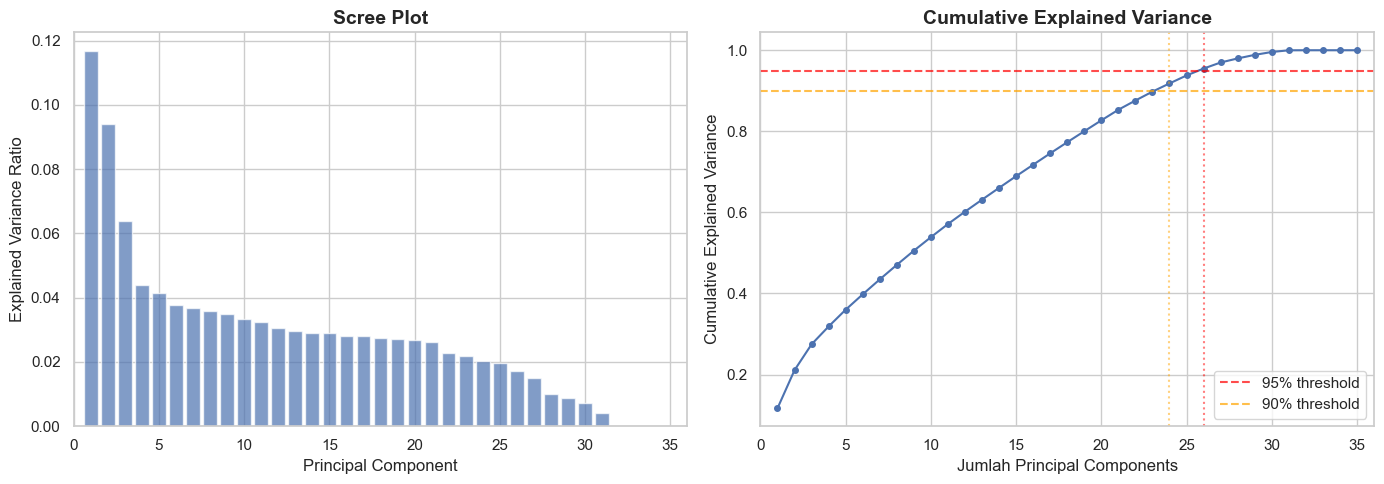

In [5]:
# Scree Plot + Cumulative Variance Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(evr)+1), evr, color='#4C72B0', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 36)

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'o-', color='#4C72B0', markersize=4)
axes[1].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].axhline(0.90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].axvline(n_95, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(n_90, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Jumlah Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 36)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

### Berapa PC yang Dipilih?

Kita gunakan **threshold 95% cumulative variance** sebagai standar umum di data mining. Ini berarti kita mempertahankan 95% informasi dari data asli sambil mereduksi dimensi.

**Trade-off jumlah PC:**
- Terlalu sedikit PC → kehilangan informasi penting, underfitting
- Terlalu banyak PC → tidak ada reduksi yang berarti, noise ikut masuk
- 95% adalah kompromi standar yang banyak digunakan dalam literatur

---
## 3. Visualisasi PCA 2D
Proyeksikan data ke 2 PC pertama untuk melihat apakah kelas terpisah secara visual.

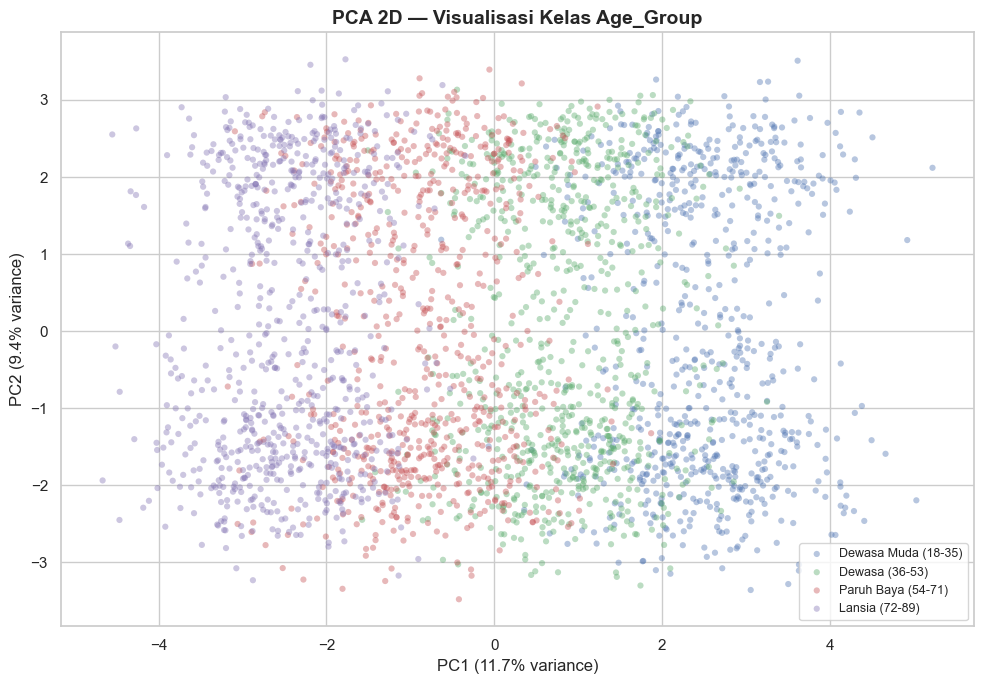

PC1 + PC2 menjelaskan 21.1% varians total


In [6]:
# PCA 2D untuk visualisasi
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for cls in range(4):
    mask = y_train == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colors[cls], label=LABEL_NAMES[cls],
               alpha=0.4, s=20, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA 2D — Visualisasi Kelas Age_Group', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PC1 + PC2 menjelaskan {sum(pca_2d.explained_variance_ratio_)*100:.1f}% varians total')

### Interpretasi Scatter Plot 2D

Dari scatter plot di atas, kita bisa melihat:
- **Kelas-kelas tidak terpisah sempurna** di ruang 2D — ini wajar karena hanya 2 PC pertama yang digunakan (menjelaskan sebagian kecil varians)
- Ada **overlap signifikan** terutama antara kelas yang bersebelahan (Dewasa Muda↔Dewasa, Paruh Baya↔Lansia)
- Pola ini konsisten dengan temuan di skenario sebelumnya: batas antar kelompok umur memang **gradual**, bukan diskrit
- Untuk klasifikasi yang baik, dibutuhkan **lebih banyak PC** — itulah mengapa kita pilih threshold 95%

---
## 4. Transformasi PCA dan Training Model
Gunakan jumlah PC yang menjelaskan 95% varians.

In [7]:
# PCA dengan 95% variance
pca = PCA(n_components=0.95, random_state=42)  # otomatis pilih jumlah PC
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

n_pc = X_train_pca.shape[1]
print(f'Jumlah PC terpilih (95% variance): {n_pc}')
print(f'Reduksi dimensi: {X_train.shape[1]} → {n_pc} ({(1-n_pc/X_train.shape[1])*100:.0f}% reduksi)')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%')

Jumlah PC terpilih (95% variance): 26
Reduksi dimensi: 35 → 26 (26% reduksi)
Total variance explained: 95.48%


In [8]:
# Evaluasi model
def evaluate_model(model, X, y, name):
    y_pred = cross_val_predict(model, X, y, cv=cv)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted')
    rec  = recall_score(y, y_pred, average='weighted')
    f1   = f1_score(y, y_pred, average='weighted')
    print(f'\n--- {name} ---')
    print(f'Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}')
    print(classification_report(y, y_pred, target_names=[LABEL_NAMES[i] for i in range(4)]))
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1, 'y_pred': y_pred}

rf_res  = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train_pca, y_train, 'Random Forest')
knn_res = evaluate_model(KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1), X_train_pca, y_train, 'KNN (k=7)')
svm_res = evaluate_model(SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42), X_train_pca, y_train, 'SVM (RBF)')


--- Random Forest ---
Acc=0.7603 | Prec=0.7578 | Rec=0.7603 | F1=0.7580
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.84      0.84      0.84       726
     Dewasa (36-53)       0.69      0.72      0.70       789
 Paruh Baya (54-71)       0.69      0.60      0.64       726
     Lansia (72-89)       0.82      0.88      0.85       759

           accuracy                           0.76      3000
          macro avg       0.76      0.76      0.76      3000
       weighted avg       0.76      0.76      0.76      3000




--- KNN (k=7) ---
Acc=0.6050 | Prec=0.6029 | Rec=0.6050 | F1=0.6037
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.72      0.73      0.73       726
     Dewasa (36-53)       0.51      0.53      0.52       789
 Paruh Baya (54-71)       0.46      0.43      0.44       726
     Lansia (72-89)       0.72      0.73      0.73       759

           accuracy                           0.60      3000
          macro avg       0.60      0.61      0.60      3000
       weighted avg       0.60      0.60      0.60      3000




--- SVM (RBF) ---
Acc=0.7587 | Prec=0.7584 | Rec=0.7587 | F1=0.7580
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.85      0.82      0.83       726
     Dewasa (36-53)       0.68      0.72      0.70       789
 Paruh Baya (54-71)       0.68      0.63      0.65       726
     Lansia (72-89)       0.83      0.87      0.85       759

           accuracy                           0.76      3000
          macro avg       0.76      0.76      0.76      3000
       weighted avg       0.76      0.76      0.76      3000



## 5. Confusion Matrix

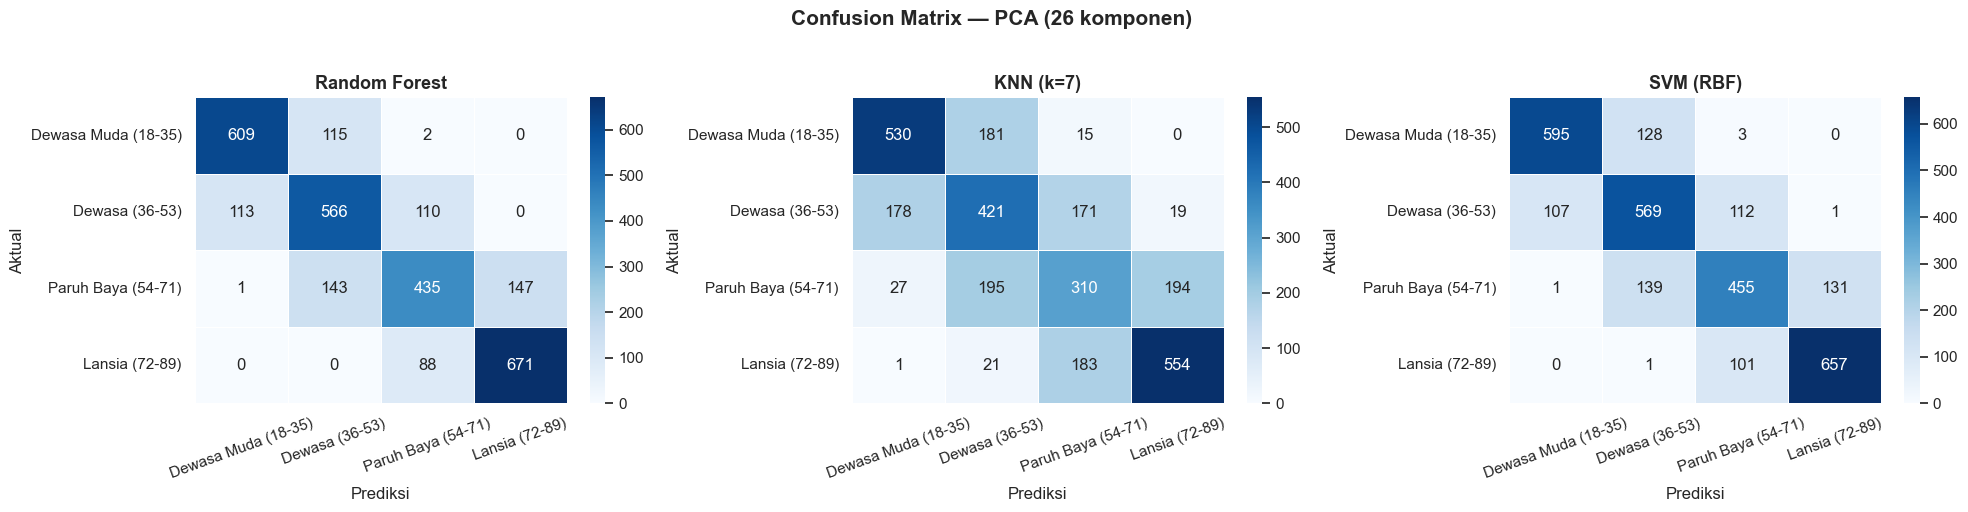

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = [LABEL_NAMES[i] for i in range(4)]
for ax, res in zip(axes, [rf_res, knn_res, svm_res]):
    cm = confusion_matrix(y_train, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, linewidths=0.5, ax=ax)
    ax.set_title(res['model'], fontsize=13, fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle(f'Confusion Matrix — PCA ({n_pc} komponen)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Perbandingan Akumulatif — 5 Skenario

In [10]:
pca_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in [rf_res, knn_res, svm_res]
]).set_index('model')
pca_results.to_csv('pca_results.csv')

# Tabel akumulatif
all_scenarios = [
    ('Baseline(35f)', baseline), ('Filter(18f)', filter_res),
    ('Wrapper', wrapper_res), ('Embedded', embedded_res),
    (f'PCA({n_pc}pc)', pca_results)
]

print('=' * 105)
print('PERBANDINGAN AKUMULATIF F1-SCORE — 5 SKENARIO')
print('=' * 105)
header = f'{"Model":20s}'
for name, _ in all_scenarios:
    header += f' | {name:>14s}'
print(header)
print('-' * 105)

for m in baseline.index:
    vals = [df.loc[m, 'f1_score'] for _, df in all_scenarios]
    best = max(vals)
    line = f'{m:20s}'
    for v in vals:
        flag = ' 🏆' if v == best else '   '
        line += f' | {v:>10.4f}{flag}'
    print(line)

PERBANDINGAN AKUMULATIF F1-SCORE — 5 SKENARIO
Model                |  Baseline(35f) |    Filter(18f) |        Wrapper |       Embedded |      PCA(26pc)
---------------------------------------------------------------------------------------------------------
Random Forest        |     0.8099    |     0.8126 🏆 |     0.8108    |     0.8060    |     0.7580   
KNN (k=7)            |     0.6117    |     0.6939    |     0.6564    |     0.7715 🏆 |     0.6037   
SVM (RBF)            |     0.7990    |     0.8020    |     0.8056    |     0.8099 🏆 |     0.7580   


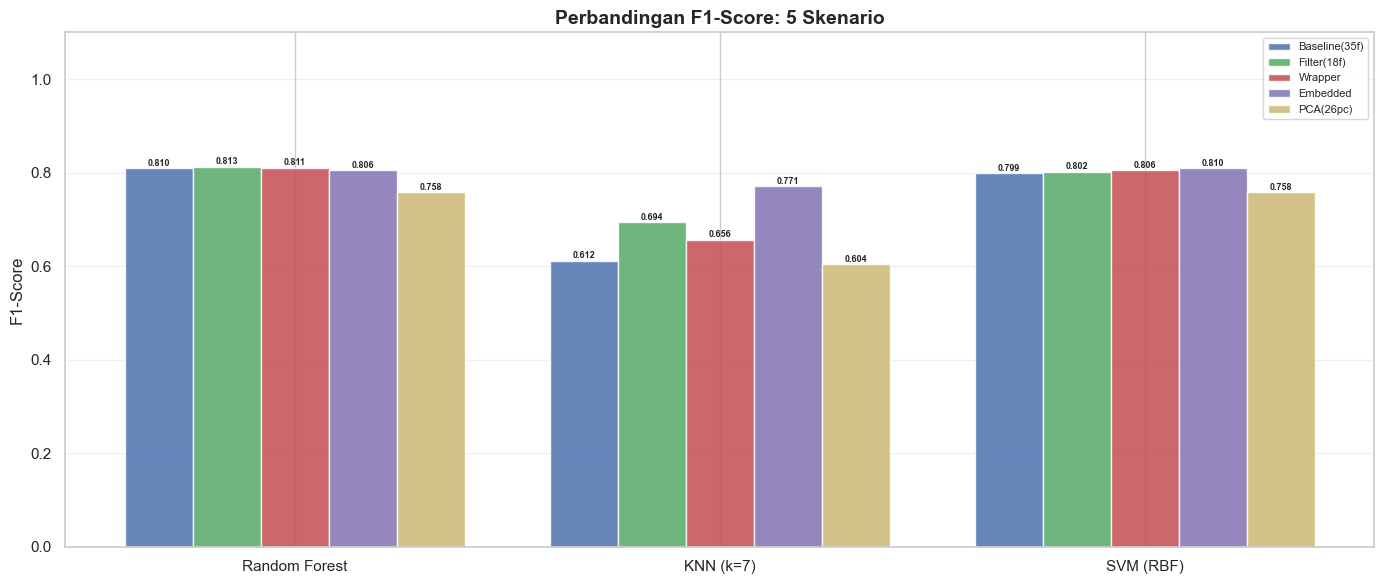

In [11]:
# Visualisasi 5 skenario
fig, ax = plt.subplots(figsize=(14, 6))
models = baseline.index.tolist()
x = np.arange(len(models))
w = 0.16
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

for i, (label, df) in enumerate(all_scenarios):
    vals = [df.loc[m, 'f1_score'] for m in models]
    bars = ax.bar(x + i*w, vals, w, label=label, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=6.5, fontweight='bold')

ax.set_xticks(x + 2*w)
ax.set_xticklabels(models)
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score: 5 Skenario', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Kesimpulan Skenario 5

### Analisis Performa PCA
- **PCA unsupervised** — tidak mempertimbangkan label kelas saat menentukan arah varians terbesar. Akibatnya, komponen utama mungkin menangkap varians yang tidak relevan untuk membedakan kelas umur.
- Bandingkan ini dengan **seleksi fitur** (B.2–B.4) yang secara eksplisit memilih fitur berdasarkan relevansinya terhadap target.

### Kapan PCA Lebih Cocok?
- Ketika fitur-fitur **sangat berkorelasi** (redundan) — PCA menggabungkannya menjadi komponen orthogonal
- Ketika **interpretabilitas** fitur tidak penting (misalnya: image recognition)
- Ketika jumlah fitur **jauh lebih banyak** dari sampel (misal: genomics, NLP)
- Untuk dataset ini (35 fitur, 3000 sampel), seleksi fitur mungkin lebih tepat karena kita masih bisa mempertahankan makna biologis

### Ekspektasi untuk Skenario B.6 (LDA)
**LDA (Linear Discriminant Analysis)** berbeda mendasar dari PCA:
- PCA: mencari arah **varians terbesar** (unsupervised)
- LDA: mencari arah **separabilitas kelas terbesar** (supervised)

**Ekspektasi**: LDA kemungkinan **lebih baik** dari PCA untuk dataset ini karena:
1. LDA secara eksplisit memaksimalkan jarak antar centroid kelas
2. Dengan 4 kelas, LDA menghasilkan maksimal 3 komponen — sangat kompak
3. Jika kelas memang terpisah secara linear (yang ditunjukkan oleh SVM yang performanya tinggi), LDA akan efektif